# Classification using tree models - full code

Dataset: HeartFailurePrediction_data

Some remarks:

- Throughout the cases, multiple bold __questions__ are stated. The goal of these questions is to guide you through the  case and to help you interpret results and steps. There are also more challenging __deepdive questions__.
- This data file has been modified for the purposes of this case <br>
- This file offers some directions one can choose from when building a model. Different choices within the modelling process can lead to different models, which are not necessarily better or worse.

**Content:**
1. [Install packages](#1)
1. [Load data](#2)
1. [Data exploration](#3)
1. [Data preparation](#4)
1. [Train and validate models](#5)
    1. [Decision Tree CART](#5a) 
    1. [Random Forest](#5b)
    1. [AdaBoost](#5c)
    1. [XGBoost](#5d)
    1. [LightGBM](#5e)
    1. [CatBoost](#5f)
    1. [Comparison of Models](#5g)
1. [SHAP](#6)   
1. [K-fold cross-validation](#7)

In [2]:
# Import packages
# 'as' := we abbreviate the package for common use        
import pandas as pd                                     # Data analysis tools               
import numpy as np                                      # Scientific computing for (multi-dimensional) arrays and matrices   
import matplotlib.pyplot as plt                         # 2D plotting library 
import seaborn as sns                                   # Data visualization library, extension of matplotlib  
import random                                           # Randomly generating numbers
import math                                             # Mathematical functions                  
import scipy.stats as stats                             # Fit of distribution plot
from sklearn.model_selection import train_test_split    # Split train-/testset     
from sklearn.tree import DecisionTreeClassifier         # Modeling CART Decision Tree  
from sklearn import metrics                             # Performance metrics
from sklearn.metrics import accuracy_score              # Accuracy of a model
from sklearn.metrics import classification_report       # Performance report of a classification model
from sklearn import tree                                # Visualizing tree 
from sklearn.ensemble import RandomForestClassifier     # Modeling Random Forest
from sklearn.ensemble import AdaBoostClassifier         # Modeling AdaBoost 
import xgboost as xgb                                   # Modeling XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import KFold               # Cross-validation using stratified K-fold


<a id="2"></a> 
## 2. Load data

In [3]:
# a) Load data file
#    Note that all decimals should be . to be read in as floats. If not, they will be read as strings.
file = "..\\data\\HeartFailurePrediction.xlsx"
inputdata = pd.read_excel(file, header=0)
# b) Save an original copy of the data
inputdata_org = inputdata.copy()    

# c) Show the first lines of the data
inputdata.head()    

,HeartDisease,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,1,54,M,ASY,200.0,198,0,Normal,142.0,Y,2.0,Flat
1,1,64,F,ASY,200.0,0,0,Normal,140.0,Y,1.0,Flat
2,1,61,M,NAP,200.0,0,1,ST,70.0,N,0.0,Flat
3,1,56,F,ASY,200.0,288,1,LVH,133.0,Y,4.0,Down
4,1,54,M,ATA,192.0,283,0,LVH,195.0,N,0.0,Up


<a id="3"></a> 
## 3. Data exploration

In [4]:
# a) Get an overview of the data
print('(nrow, ncol):', inputdata.shape)     # Get the number of rows and columns

(nrow, ncol): (918, 12)


In [5]:
# b) Check data types of all variables
inputdata.dtypes

HeartDisease        int64
Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR             float64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
dtype: object

In [6]:
# c) Univariate analysis
#    i. Show a brief summary of the variables
inputdata.describe()                 # min/max, count, mean, std and percentiles

,HeartDisease,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,917.000000,918.000000,918.000000,918.000000,918.000000
mean,0.553377,53.510893,132.392585,202.976035,0.233115,139.441721,0.887364
std,0.497414,9.432617,18.523874,145.067237,0.423046,65.354817,1.066570
min,0.000000,28.000000,0.000000,0.000000,0.000000,13.500000,-2.600000
25%,0.000000,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,1.000000,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,1.000000,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,1.000000,77.000000,200.000000,2680.000000,1.000000,1600.000000,6.200000


__Question:__ when looking at the statistics presented above, are there any reasons to doubt the validity of all observations?

In [7]:
#    ii. Get an overview of the NULLS in the dataset
nulls = inputdata.isnull().sum()                          # Number of NULLS 
percNulls = inputdata.isnull().sum()/inputdata.shape[0]   # Number of NULLS as a percentage

pd.concat({"# NULLS": nulls, "% NULLS": percNulls*100}, axis=1)

,# NULLS,% NULLS
HeartDisease,0,0.000000
Age,0,0.000000
Sex,0,0.000000
ChestPainType,2,0.217865
RestingBP,1,0.108932
Cholesterol,0,0.000000
FastingBS,0,0.000000
RestingECG,1,0.108932
MaxHR,0,0.000000
ExerciseAngina,4,0.435730


In [8]:
# iii. Delete all entries with missing variables, and verify that there are indeed no more zero-entries

inputdata = inputdata.dropna()

nulls = inputdata.isnull().sum()                          # Number of NULLS 
percNulls = inputdata.isnull().sum()/inputdata.shape[0]   # Number of NULLS as a percentage

pd.concat({"# NULLS": nulls, "% NULLS": percNulls*100}, axis=1)

,# NULLS,% NULLS
HeartDisease,0,0.0
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0


As you can see, deleting observations is the easiest way to tackle the issue of missing variables. However, this is not always the best way to do so.

__Deepdive question:__ under what circumstances is it okay to delete observations as a way to tackle missing variables? Moreover, what could be a better way to deal with the issue?

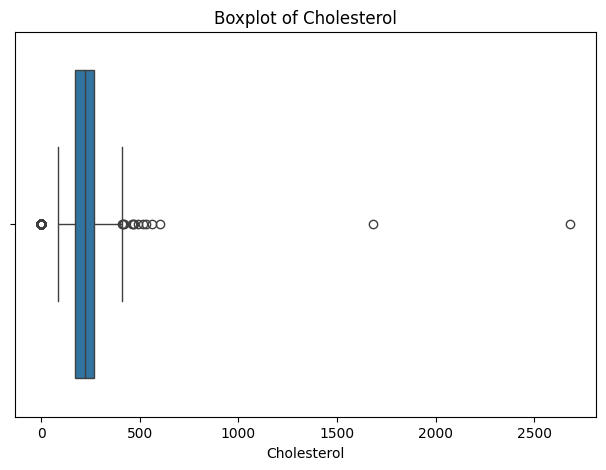

In [9]:
#    iv. Create boxplot
# Adjust the line below to also find boxplots for other numerical variables.
x = 'Cholesterol'
plt.figure(figsize=(7.5,5))
sns.boxplot(x=inputdata[x])
plt.title("Boxplot of " + x)
plt.xlabel(x)
plt.show()

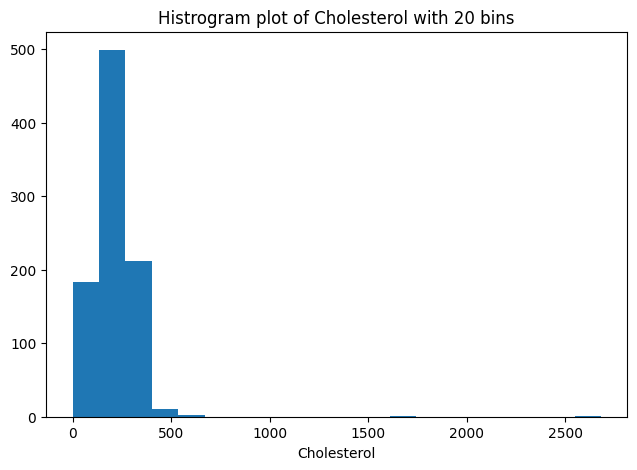

In [10]:
#    v. Create histogram 
x = 'Cholesterol'
num_bins = 20
plt.figure(figsize=(7.5,5))
plt.hist(inputdata[x], num_bins)
plt.title("Histrogram plot of " + x + " with " + str(num_bins) + " bins")
plt.xlabel(x)
plt.show()

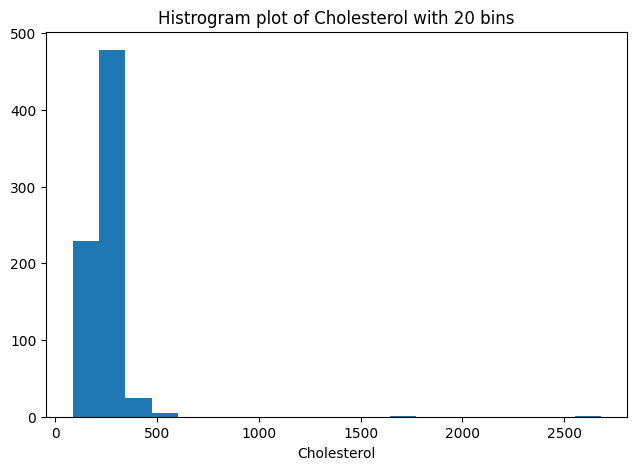

In [11]:
# vi. Delete all zero-values for Cholesterol and create a new histogram
# A cholesterol-value of zero does not make any sense. So, we delete all entries where cholesterol equals zero.
inputdata = inputdata[(inputdata['Cholesterol'] > 0)]
x = 'Cholesterol'
num_bins = 20
plt.figure(figsize=(7.5,5))
plt.hist(inputdata[x], num_bins)
plt.title("Histrogram plot of " + x + " with " + str(num_bins) + " bins")
plt.xlabel(x)
plt.show()                      

Deleting observations where the value for Cholesterol is zero is the easiest way to solve this issue.

__Deepdive question:__ we again decide to delete observations that have a Cholesterol value of zero. However, in this case, this is the case for a substantial part of observations. What is (especially in this case) the risk of deciding to 'just delete' these observations? Furthermore, how can we check if we can validly do so? Lastly, if we can't, what would be a better way to deal with the issue?

<Figure size 750x500 with 0 Axes>

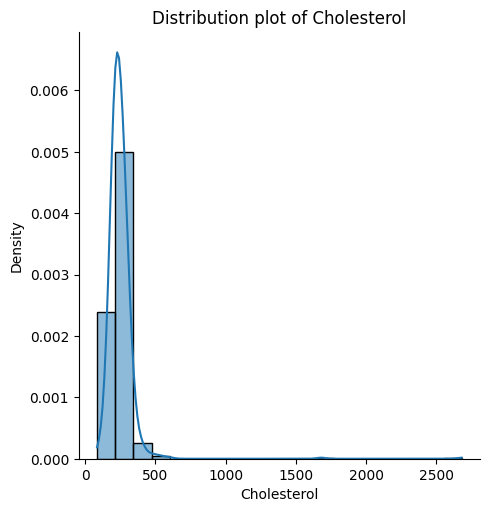

In [12]:
#    vii. Create distribution plot
x = 'Cholesterol'

plt.figure(figsize=(7.5,5))
sns.displot(data=inputdata[~np.isnan(inputdata[x])][x], stat='density', bins=20, kde=True)
plt.title("Distribution plot of " + x) 
plt.xlabel(x)
plt.show()

In [13]:
# d) Multivariate analysis
#    i. Count frequency of a variable
y = 'HeartDisease'
x = 'ChestPainType'
number = inputdata[x].value_counts()            # Get number per 'Count_variable'
average = inputdata.groupby(x)[y].mean()        # Get average of variable per 'Count_variable'           

pd.concat({"Number of " + x: number, "Mean of " + y + " per " + x: average}, axis=1)

,Number of ChestPainType,Mean of HeartDisease per ChestPainType
ChestPainType,,
ASY,365,0.742466
NAP,169,0.272189
ATA,163,0.122699
TA,41,0.365854


<Figure size 750x500 with 0 Axes>

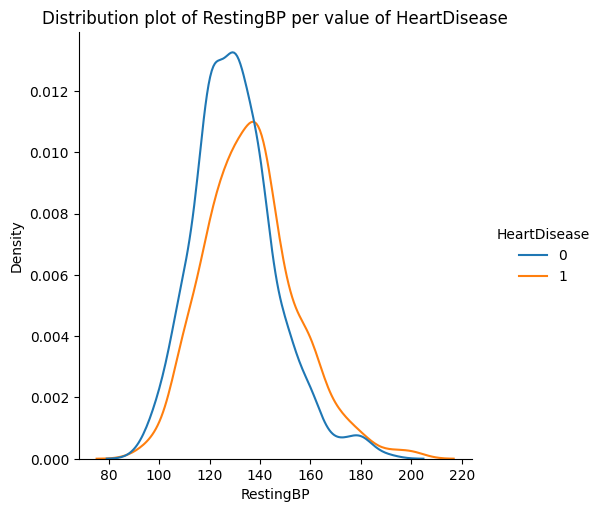

In [14]:
#    iii. Create distribution plot for two variables
y = 'HeartDisease'
x = 'RestingBP'
plt.figure(figsize=(7.5,5))
sns.displot(data=inputdata, x=x, hue=y, kind='kde', label='True')
plt.title("Distribution plot of " + x + " per value of " + y)
plt.xlabel(x)
plt.show()

__Question:__ what information does this graph reveal? Is it in line with your intuition?

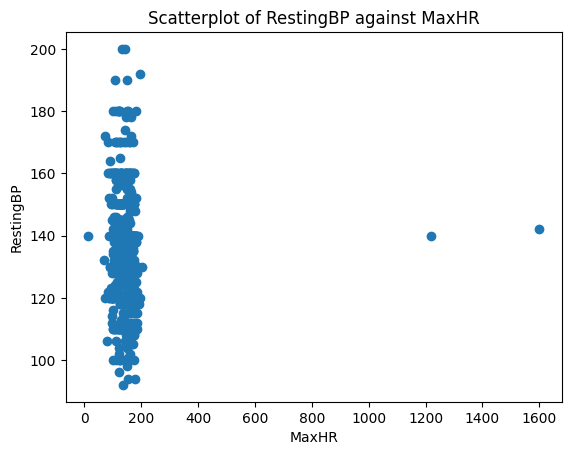

In [15]:
#    iv. Create scatterplot for two variables
y = 'RestingBP'
x = 'MaxHR'
plt.scatter(inputdata[x], inputdata[y], marker='o')
plt.title("Scatterplot of " + y + " against " + x)
plt.ylabel(y)
plt.xlabel(x)
plt.show()

__Deepdive question:__ notice that there seems to be some correlation between RestingBP (resting blood pressure) and MaxHR (maximum heart rate achieved). How would you test whether this is indeed the case? Moreover, if there turns out to be a correlation between the two, does this correlation also imply that there is a causal effect? Why (not)? What factor could also play a role here?

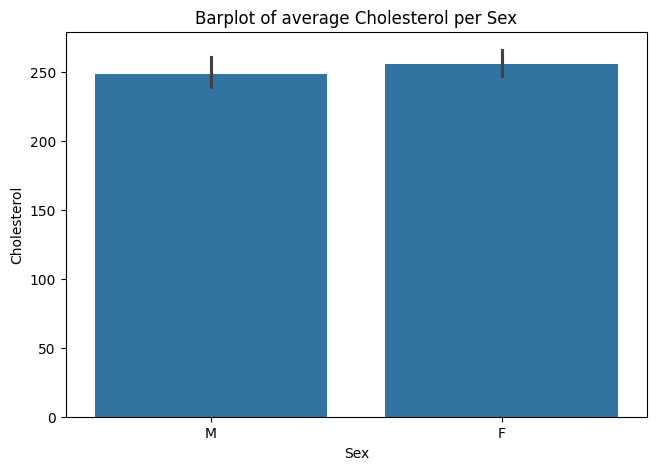

In [16]:
#    v. Create barplot for two variables
y = 'Cholesterol'
x = 'Sex'
plt.figure(figsize=(7.5,5))
sns.barplot(x=inputdata[x], y=inputdata[y])
plt.title("Barplot of average " + y + " per " + x)
plt.ylabel(y)
plt.xlabel(x)
plt.show()

__Deepdive question:__ according to this graph, women have a higher Cholesterol level than men. What else should we check before we come to this conclusion for the general population? Moreover, how would we take this fact into account when building our models?

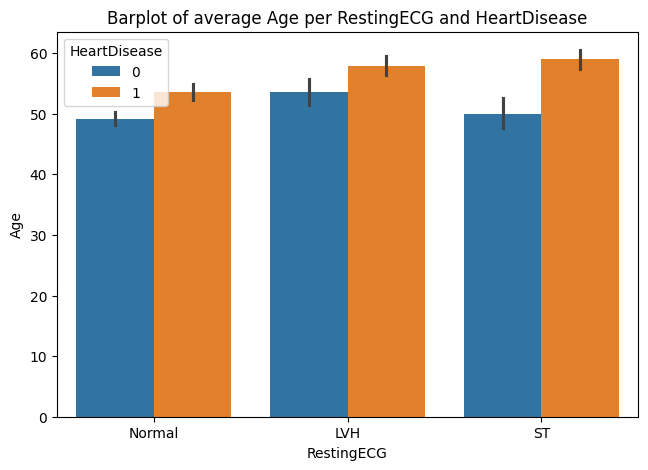

In [17]:
#    vi. Create barplot for three variables
y  = 'Age'
x1 = 'RestingECG'
x2 = 'HeartDisease'
plt.figure(figsize=(7.5,5))
sns.barplot(data=inputdata, x=inputdata[x1], y=inputdata[y], hue=inputdata[x2],)
plt.title("Barplot of average " + y + " per " + x1 + " and " + x2) 
plt.ylabel(y)
plt.xlabel(x1)
plt.show()

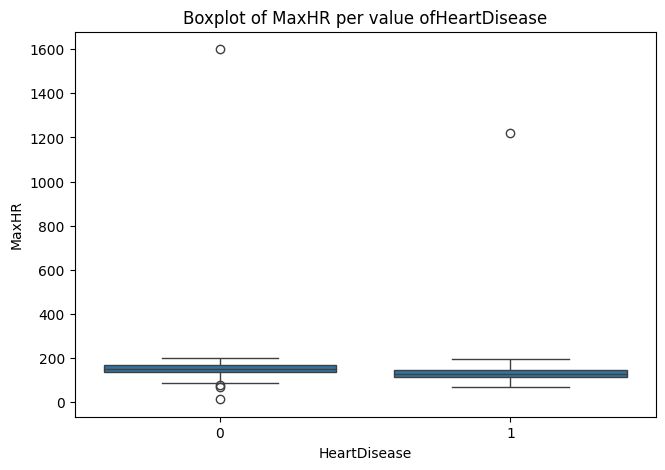

In [18]:
#    vii. Create boxplot for two variables
y = 'MaxHR'
x = 'HeartDisease'
plt.figure(figsize=(7.5,5))
sns.boxplot(x=inputdata[x], y=inputdata[y])
plt.title("Boxplot of " + y + " per value of" + x)
plt.ylabel(y)
plt.xlabel(x)
plt.show()

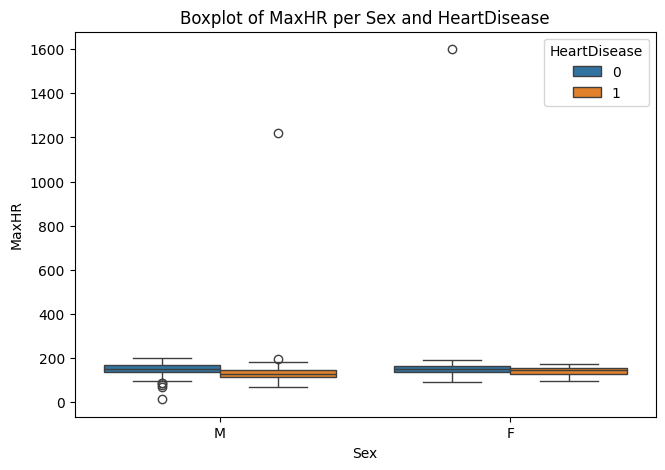

In [19]:
#    viii. Create boxplot for three variables
y  = 'MaxHR'
x1 = 'Sex'
x2 = 'HeartDisease'
plt.figure(figsize=(7.5,5))
sns.boxplot(x=x1, y=y, hue=x2, data=inputdata)
plt.title("Boxplot of " + y + " per " + x1 + " and " + x2) 
plt.ylabel(y)
plt.xlabel(x1)
plt.show()

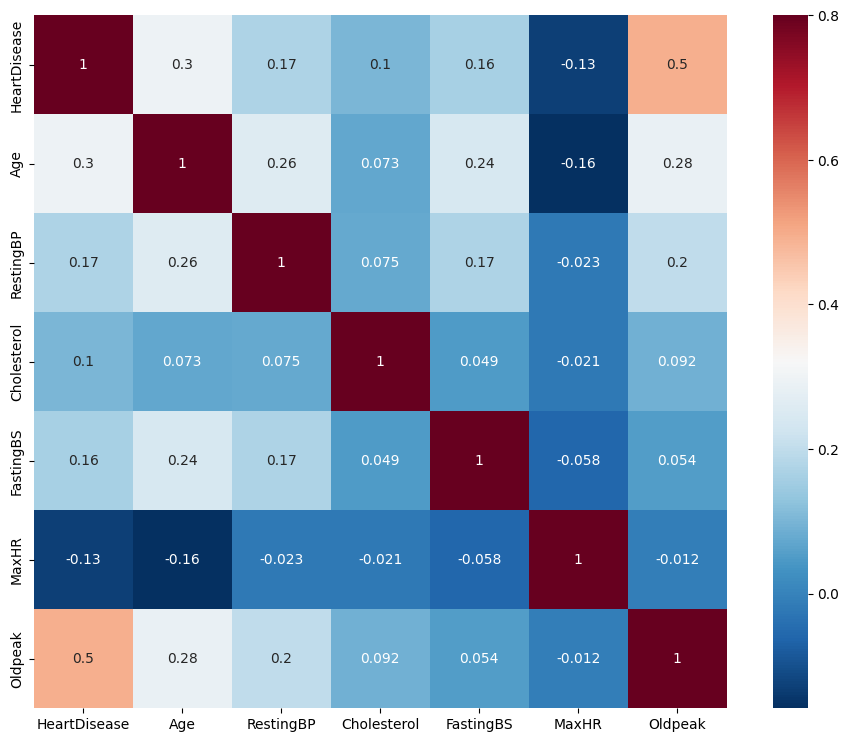

In [20]:
# Create correlation matrix for numerical variables
# Pro: Can you include non numerical variables with labels?
corrmat = inputdata.select_dtypes(include='number').corr()
plt.figure(figsize=(12,9))
sns.heatmap(corrmat, annot=True, cmap='RdBu_r', square=True, vmax=.8)
plt.show()

__Deepdive question:__ how can this correlation matrix help us build a good model? For example, what variable seems to have most predictive power for heart diseases? Are there any multicollineary effects that we might consider taking into account?

<a id="4"></a> 
## 4. Data preparation

<Figure size 750x500 with 0 Axes>

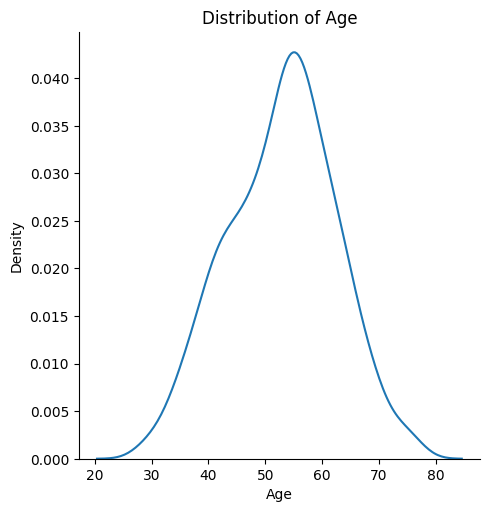

C:\Users\WoutervanWessel\AppData\Local\Temp\ipykernel_24220\3513106382.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inputdata[outlier][inputdata[outlier]>110] = mode_outlier.iloc[0]


In [21]:
# a) Handling outliers
x = 'Age'
plt.figure(figsize=(7.5,5))
sns.displot(data=inputdata, x=inputdata[~inputdata[x].isna()][x],kind='kde')
plt.title("Distribution of " + x) 
plt.xlabel(x)
plt.show()

#    Fill the outlier values with the mean, median, most common value, maximum or minimum
outlier = 'Age'
mode_outlier = round(inputdata[outlier].mode()).astype('int')
inputdata[outlier][inputdata[outlier]>110] = mode_outlier.iloc[0]

__Question:__ what could be a downside of replacing cells with outliers with the mean, when the outliers are extremely high values?

__Question:__ what is a good way to identify outliers? In other words, how do you decide the cut-off value for an observation to be an outlier?

In [22]:
# b) Dummify variables
to_dummify = ['Sex'           # ADD ALL VARIABLES YOU WISH TO DUMMIFY 
              ,'ChestPainType',
              'FastingBS',
              'RestingECG',
              'ExerciseAngina',
              'ST_Slope'
             ]
dummified_columns = inputdata[to_dummify]                      # Save the original columns
inputdata = pd.get_dummies(inputdata, columns=to_dummify)      # Dummify the columns
inputdata = pd.concat([inputdata, dummified_columns], axis=1)  # Join the original columns to the new dataframe

Now, different variables have been turned into dummy variables. For example, 'Sex' has been split up into 'Sex_M' and 'Sex_F', to which the value 1 is assigned is an observation is male or female respectively.

__Question:__ what should we definetely take into account when we want to use these dummy variables when building our model?

#### Feature engineering

You can achieve a lot by creating new features and implementing these in the models. Can you improve the classification models by creating and adding new features?

In [23]:
inputdata['Interaction_RestingBP_Man'] = inputdata['RestingBP'] * inputdata['Sex_M'].astype('float')

to_dummy = 'Cholesterol'
inputdata['High_Cholesterol'] = np.where(inputdata[to_dummy]>350, 1, 0) # Create a feature that sets apart high Cholesterol.
inputdata.head(10)

,HeartDisease,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,...,ST_Slope_Flat,ST_Slope_Up,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,Interaction_RestingBP_Man,High_Cholesterol
0,1,54,200.0,198,142.0,2.0,False,True,True,False,...,True,False,M,ASY,0,Normal,Y,Flat,200.0,0
3,1,56,200.0,288,133.0,4.0,True,False,True,False,...,False,False,F,ASY,1,LVH,Y,Down,0.0,0
4,1,54,192.0,283,195.0,0.0,False,True,False,True,...,False,True,M,ATA,0,LVH,N,Up,192.0,0
5,0,39,190.0,241,106.0,0.0,False,True,False,True,...,False,True,M,ATA,0,Normal,N,Up,190.0,0
6,1,61,190.0,287,150.0,2.0,False,True,True,False,...,False,False,M,ASY,1,LVH,Y,Down,190.0,0
8,1,58,180.0,393,110.0,1.0,True,False,False,True,...,True,False,F,ATA,0,Normal,Y,Flat,0.0,1
9,1,53,180.0,285,120.0,1.5,False,True,True,False,...,True,False,M,ASY,0,ST,Y,Flat,180.0,0
10,0,46,180.0,280,120.0,0.0,False,True,True,False,...,False,True,M,ASY,0,ST,N,Up,180.0,0
11,0,45,180.0,295,180.0,0.0,True,False,False,True,...,False,True,F,ATA,0,Normal,N,Up,0.0,0
12,0,59,180.0,213,100.0,0.0,False,True,False,False,...,False,True,M,NAP,0,Normal,N,Up,180.0,0


As you can see, as an example, we have added two new variables. 

1. We have added an interaction term between the dummy 'Sex_M' and 'RestingBP'. This is because resting blood pressure differs for men and women, according to the literature. 
2. We have also added a new dummy variable that takes the value '1' when Cholesterol is especially high (>350).

__Deepdive question:__ what other features can you think of in the feature engineering phase that might improve the model?

#### Split into train- and testset

In [24]:
data_train, data_test  = train_test_split(inputdata, test_size=0.3, random_state=123)

__Question__: note that we only spilt the data set into two parts after we did the different explorative analyses. According to some, it is better to make the split before the data exporation. Can you think of a reason why?

<a id="5"></a> 
## 5. Train and validate models

<a id="5a"></a> 
### A) Decision Tree CART

In [25]:
# Define X and y 
X_variables = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','Sex_M'
               # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable].astype('int')
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable].astype('int')

In [26]:
# a) Set model parameters 
#    Note: if Min_bucket is too large, the tree might not branch, if too small, the tree might get to big to interpret
Min_num_splits = 5                           # Minimum number of items to split
Min_bucket     = 3                          # Minimum number of items per bucket
Max_depth      = 5                           # Maximum depth of final tree (nr of levels)

__Question:__ how does the model change when you increase the min_num_splits? How about if you decrease max_depth?

__Question:__ discuss what you think are the best values are for these parameters.

In [27]:
# b) Estimate the model 
mytree = DecisionTreeClassifier(max_depth=Max_depth
                                ,min_samples_split=Min_num_splits
                                ,min_samples_leaf=Min_bucket
                                ,criterion="gini"              
                                ,splitter="best"
                                ,random_state=random.seed()
                                )

mytree.fit(X_train, y_train)     # Fit the model over the train set

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
# c) Create predictions for the test set
preds_proba = mytree.predict_proba(X_test)
preds = mytree.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.880952,0.119048,0
1,0.880952,0.119048,0
2,0.000000,1.000000,1
3,0.659091,0.340909,0
4,0.791667,0.208333,0


In [29]:
#     Calculate the optimal cut-off point given these theoretical costs.

cost_TP = 0
cost_TN = 0
cost_FP = 50
cost_FN = 100
total_cost = math.inf

for i in np.linspace(0,1,100,endpoint=False):
    y_pred = (preds_proba[:,1]>i).astype('int')
    results = metrics.confusion_matrix(y_pred,y_test)
    TN = results[0][0]
    FN = results[0][1]
    FP = results[1][0]
    TP = results[1][1]
    
    # Calculate cutoff-point
    cost = TN*cost_TN + TP*cost_TP + FP*cost_FP + FN*cost_FN
    total_cost = min(total_cost,cost)
    if(total_cost == cost):
        opt_cutoff = i
        
print('Optimal cut-off:', opt_cutoff)

#    Create predictions for the test set according to optimal cutoff point
preds = (preds_proba[:,1] > opt_cutoff).astype('int')

Optimal cut-off: 0.2


__Question:__ How would the results change if the cost of False Positives (cost_FP) increased to 100?

__Question:__ What could be a reason for the costs of false negatives to be higher than the costs of false positives in this situation? Can you come up with a situation in which the relation it is the other way around?

In [30]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0    1
row_0                
0             54   13
1             52  103


In [31]:
#    ii. Create classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.81      0.51      0.62       106
           1       0.66      0.89      0.76       116

    accuracy                           0.71       222
   macro avg       0.74      0.70      0.69       222
weighted avg       0.73      0.71      0.70       222



__Question:__ what do you think when you see the results? Does the model perform as hoped / expected?

Feature ranking:
Feature 4 (Oldpeak) 0.518172
Feature 3 (MaxHR) 0.257972
Feature 5 (Sex_M) 0.074588
Feature 0 (Age) 0.057356
Feature 2 (Cholesterol) 0.051314
Feature 1 (RestingBP) 0.040597


<Figure size 750x500 with 0 Axes>

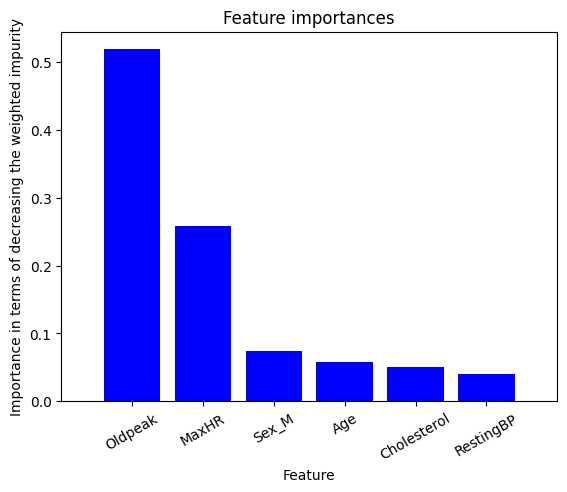

In [32]:
#    iii. Get the feature importances of the tree
importances = mytree.feature_importances_ 
std = np.std([mytree.feature_importances_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])

plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
       color="blue", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

__Question:__ How would you explain this graph to a non analytical expert?

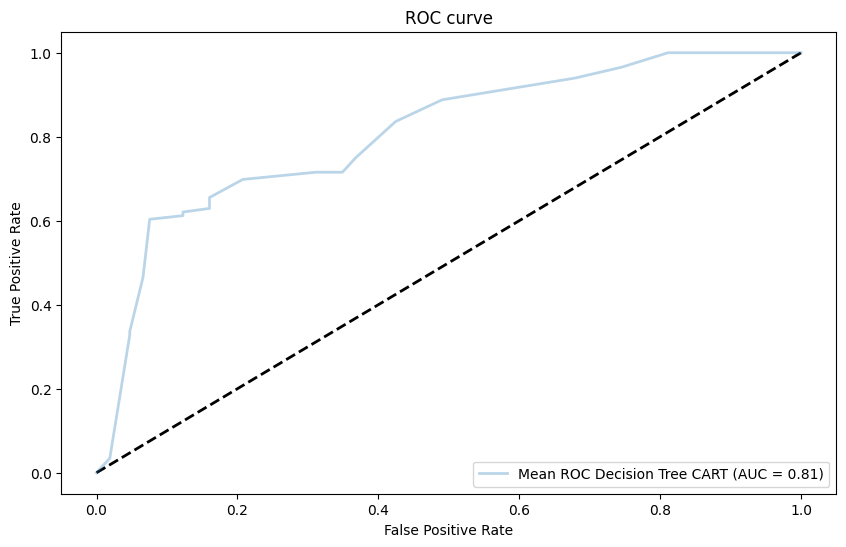

In [33]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
roc_auc_tree = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC Decision Tree CART (AUC = %0.2f)' % (roc_auc_tree))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

__Question:__ what does this ROC curve imply for how accurate your diagnosis is?

__Question:__ what information does this graph portray? What is the meaning of the intersection between the red and the blue line? 

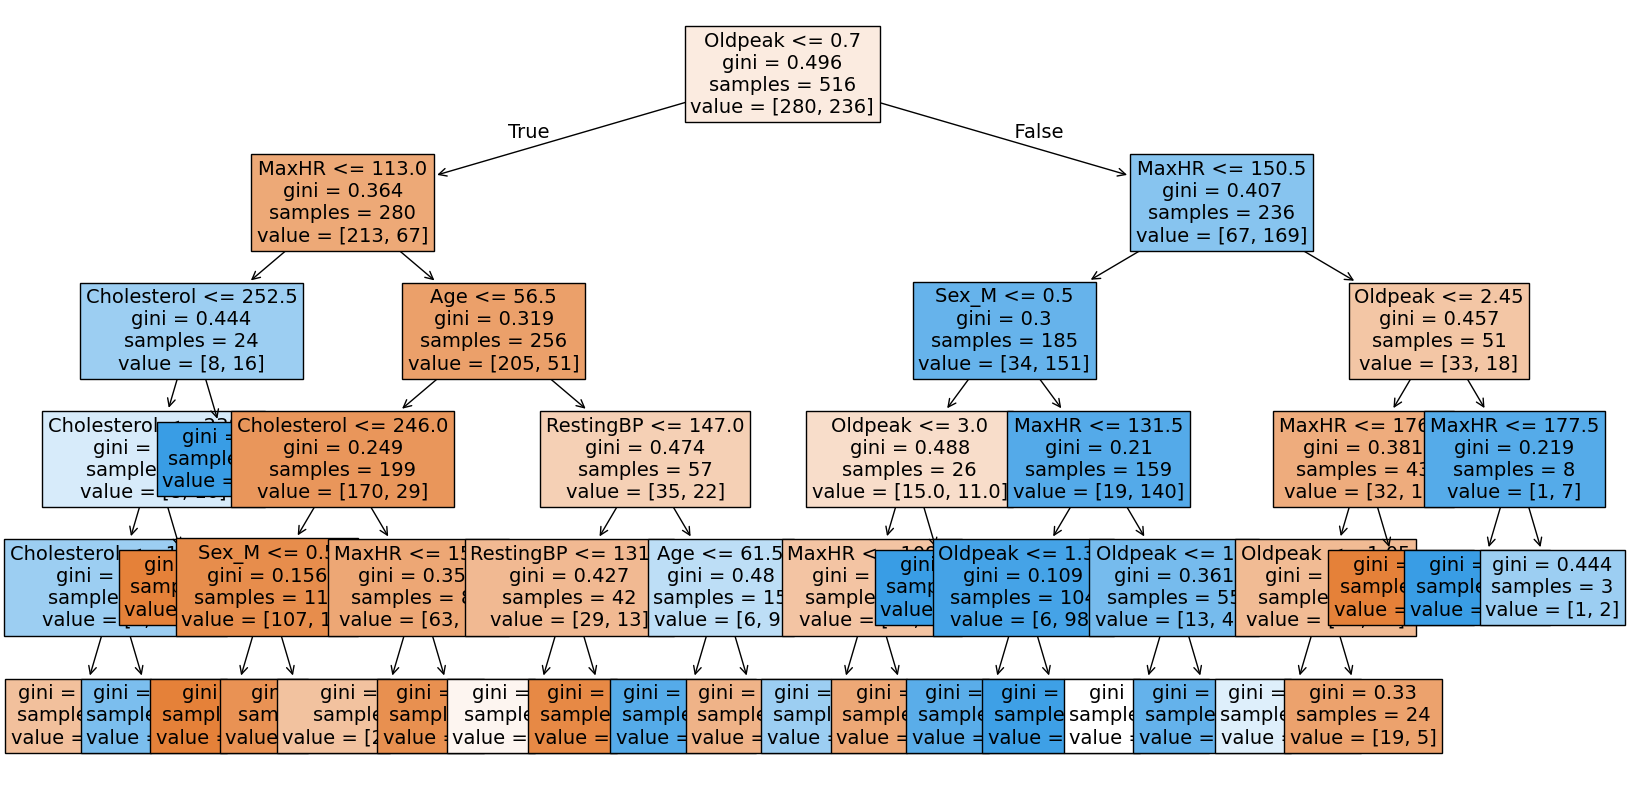

In [34]:
# e) Visualize Decision Tree

plt.figure(figsize=(20, 10))  # width=20, height=10 inches
tree.plot_tree(mytree, feature_names=X_variables, filled=True, fontsize=14)
plt.show()

<a id="5c"></a> 
### B) Random Forest 

In [35]:
# Define X and y 
X_variables = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','Sex_M'
               # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

In [36]:
# a) Set model parameters 
#     Note: You can tweak the size of your forest by changing 'N_trees', but note computation time increases with size
#     Note: if Min_bucket is too large, the trees might not branch
N_trees        = 1000                           # Number of trees that are estimated
Min_num_splits = 5                           # Minimum number of items to split    
Min_bucket     = 5                           # Minimum number of items per bucket
Max_depth      = 4                           # Maximum depth of each tree (nr of levels)

In [37]:
# b) Estimate the model
forest = RandomForestClassifier(n_estimators = N_trees
                                ,criterion = "gini"            
                                ,max_depth = Max_depth
                                ,min_samples_split = Min_num_splits
                                ,min_samples_leaf = Min_bucket
                                ,random_state = random.seed()
                                )

forest.fit(X_train, y_train)   # Fit the model over the train set

,n_estimators,1000
,criterion,'gini'
,max_depth,4
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# c) Create predictions for the test set
preds_proba = forest.predict_proba(X_test)
preds = forest.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.853017,0.146983,0
1,0.783238,0.216762,0
2,0.371422,0.628578,1
3,0.733382,0.266618,0
4,0.436711,0.563289,1


In [39]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0   1
row_0               
0             86  34
1             20  82


In [40]:
#    ii. Create classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.72      0.81      0.76       106
           1       0.80      0.71      0.75       116

    accuracy                           0.76       222
   macro avg       0.76      0.76      0.76       222
weighted avg       0.76      0.76      0.76       222



Feature ranking:
Feature 4 (Oldpeak) 0.371199
Feature 3 (MaxHR) 0.266618
Feature 0 (Age) 0.160607
Feature 5 (Sex_M) 0.102211
Feature 2 (Cholesterol) 0.052305
Feature 1 (RestingBP) 0.047060


<Figure size 750x500 with 0 Axes>

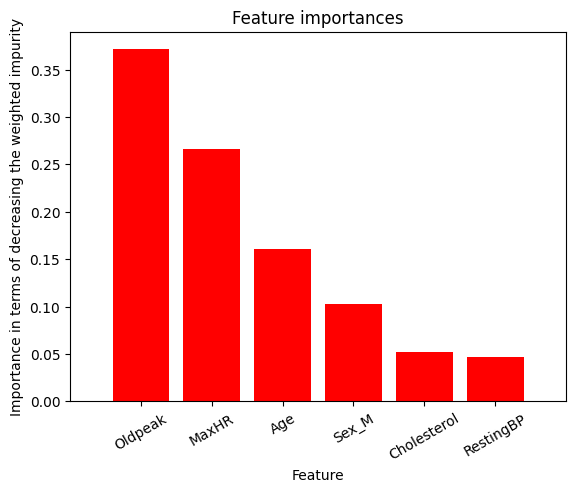

In [41]:
#    iii. Get the feature importances of the forest
importances = forest.feature_importances_ 
std = np.std([forest.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])

plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

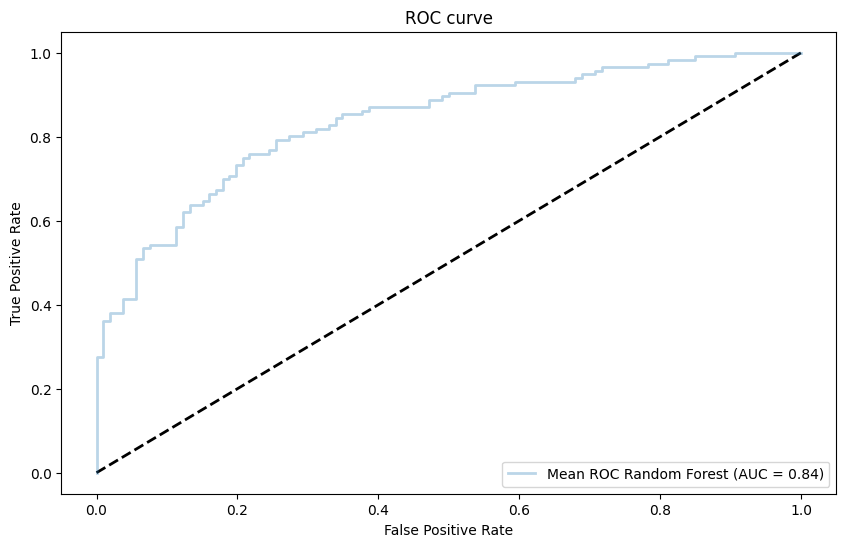

In [42]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
roc_auc_forest = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC Random Forest (AUC = %0.2f)' % (roc_auc_forest))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

<a id="5d"></a> 
### C) ADABOOST (Adaptive Boosting Model)

In [43]:
# Define X and y 
X_variables = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','Sex_M'
               # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

In [44]:
# a) Set model parameters 
#     Note: You can tweak the size of your boost by changing 'N_trees', but note computation time increases with size
#     Note: if Min_bucket is too large, the trees might not branch
N_trees        = 1000                           # Number of trees that are estimated
Min_num_splits = 4                           # Minimum number of items to split    
Min_bucket     = 3                           # Minimum number of items per bucket
Max_depth      = 3                           # Maximum depth of each tree (nr of levels)
Learning_rate  = 1                           # The learning rate

In [45]:
# b) Estimate model
adaptboost = AdaBoostClassifier(n_estimators=N_trees
                                ,estimator=DecisionTreeClassifier(max_depth = Max_depth
                                                                       ,min_samples_split = Min_num_splits
                                                                       ,min_samples_leaf = Min_bucket
                                                                       ,criterion = "gini"              
                                                                       ,splitter = "best"
                                                                       )
                                ,learning_rate=Learning_rate
                               )

adaptboost.fit(X_train, y_train)      # Fit the model over the train set

,estimator,DecisionTreeC...mples_split=4)
,n_estimators,1000
,learning_rate,1
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,4
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0


In [46]:
# c) Create predictions for the test set
preds_proba = adaptboost.predict_proba(X_test)
preds = adaptboost.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.570415,0.429585,0
1,0.484530,0.515470,1
2,0.461062,0.538938,1
3,0.510738,0.489262,0
4,0.469943,0.530057,1


In [47]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0   1
row_0               
0             78  37
1             28  79


In [48]:
#    ii. Create classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       106
           1       0.74      0.68      0.71       116

    accuracy                           0.71       222
   macro avg       0.71      0.71      0.71       222
weighted avg       0.71      0.71      0.71       222



Feature ranking:
Feature 2 (Cholesterol) 0.323735
Feature 3 (MaxHR) 0.211238
Feature 0 (Age) 0.192998
Feature 1 (RestingBP) 0.153868
Feature 4 (Oldpeak) 0.099413
Feature 5 (Sex_M) 0.018748


<Figure size 750x500 with 0 Axes>

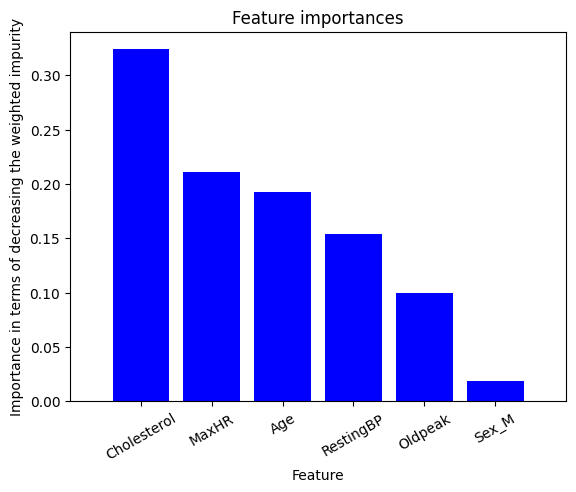

In [49]:
#    iii. Get the feature importances of the Adaboost
importances = adaptboost.feature_importances_ 
std = np.std([adaptboost.feature_importances_ for tree in adaptboost.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])

plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
       color="blue", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

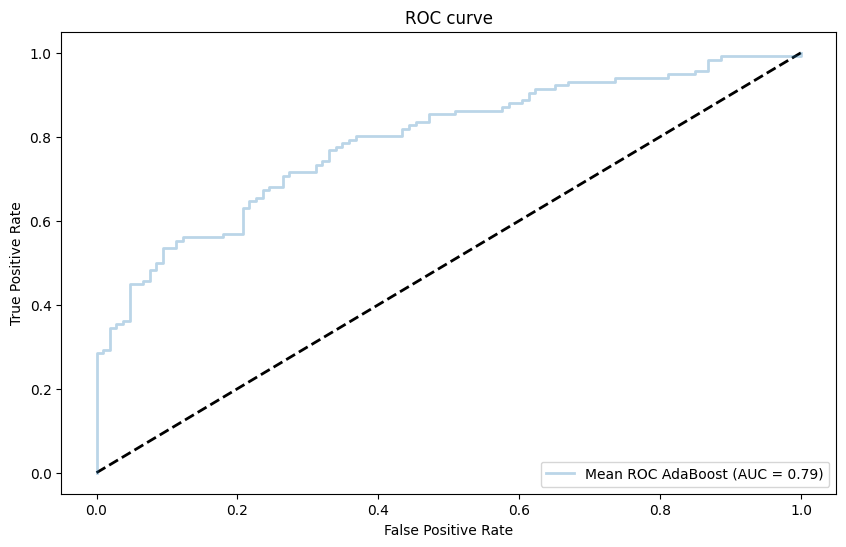

In [50]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
roc_auc_adaboost = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC AdaBoost (AUC = %0.2f)' % (roc_auc_adaboost))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

c:\Users\WoutervanWessel\Documents\Coding\Tree Based Modelling\Cases\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 0, 'Number of estimators')

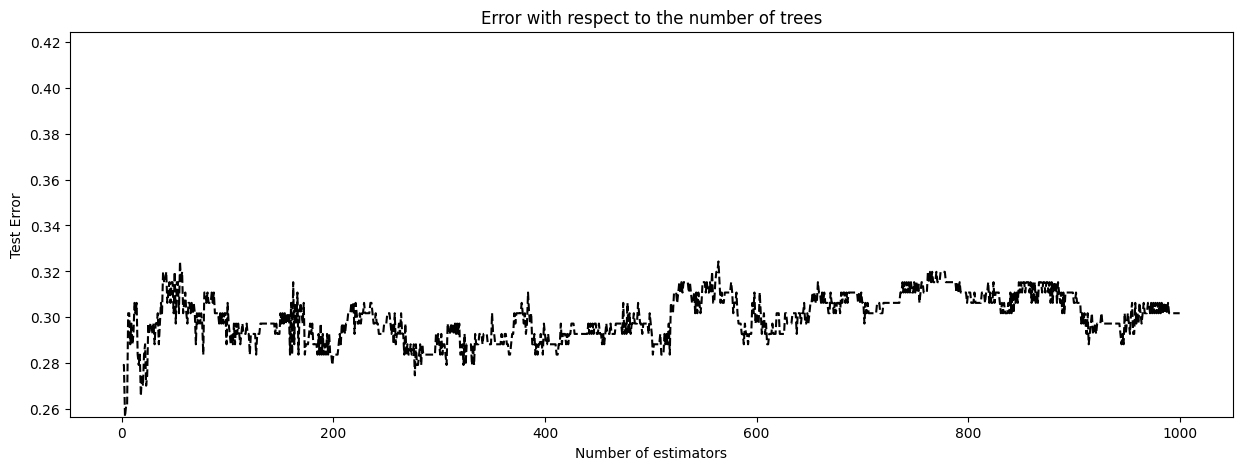

In [51]:
# e) Plot error with respect to number of estimators (trees)
trained_adaptboost = adaptboost.fit(X_train, y_train)  

real_test_errors = []
for real_test_predict in trained_adaptboost.staged_predict(X_test):
    real_test_errors.append(1. - accuracy_score(real_test_predict, np.ravel(y_test)))
n_trees_real = len(trained_adaptboost)
real_estimator_errors = trained_adaptboost.estimator_errors_[:n_trees_real]
plt.figure(figsize=(15, 5))

plt.plot(range(1, n_trees_real + 1),
         real_test_errors, c='black',
         linestyle='dashed')
plt.ylim(min(real_test_errors), max(real_test_errors)+0.1)
plt.title('Error with respect to the number of trees')
plt.ylabel('Test Error')
plt.xlabel('Number of estimators')

<a id="5e"></a> 
### D) XGBoost

In [52]:
# Define X and y 
X_variables = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','Sex_M'
               # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

In [53]:
# a) Set model parameters 
N_trees        = 1000                          # Number of trees that are estimated
Max_depth      = 4                           # Maximum depth of each tree (nr of levels)
Learning_rate  = 1                           # The learning rate ('eta')
Min_bucket     = 3                           # Minimum number of items per bucket
Subsample      = 0.5                           # Subsample ratio of the training instance
Silent         = 0                           # Whether to print messages while running boosting

In [54]:
# b) Estimate model
XGB = xgb.XGBClassifier(n_estimators=N_trees
                        ,max_depth=Max_depth 
                        ,learning_rate=Learning_rate
                        ,min_child_weight=Min_bucket
                        ,subsample=Subsample
                        ,silent=Silent
                       )

XGB.fit(X_train, y_train)      # Fit the model over the train set

c:\Users\WoutervanWessel\Documents\Coding\Tree Based Modelling\Cases\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:33:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
# c) Create predictions for the test set
preds_proba = XGB.predict_proba(X_test)
preds = XGB.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.982456,0.017544,0
1,0.925690,0.074310,0
2,0.703298,0.296702,0
3,0.148696,0.851304,1
4,0.002403,0.997597,1


In [56]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0   1
row_0               
0             69  34
1             37  82


In [57]:
#    ii. Create classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.67      0.65      0.66       106
           1       0.69      0.71      0.70       116

    accuracy                           0.68       222
   macro avg       0.68      0.68      0.68       222
weighted avg       0.68      0.68      0.68       222



Feature ranking:
Feature 5 (Sex_M) 0.272873
Feature 4 (Oldpeak) 0.152454
Feature 3 (MaxHR) 0.152377
Feature 1 (RestingBP) 0.143027
Feature 2 (Cholesterol) 0.140978
Feature 0 (Age) 0.138292


<Figure size 750x500 with 0 Axes>

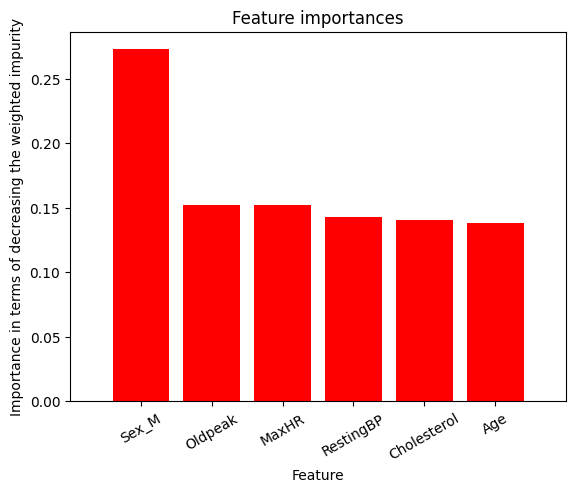

In [58]:
#    iii. Get the feature importances of the XGBoost
importances = XGB.feature_importances_ 
std = np.std([XGB.feature_importances_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])

plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

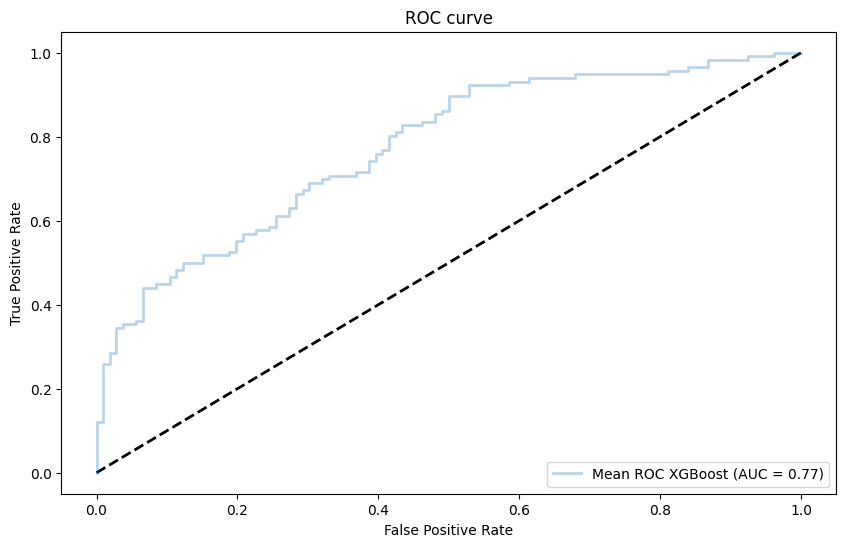

In [59]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
roc_auc_xgboost = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC XGBoost (AUC = %0.2f)' % (roc_auc_xgboost))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

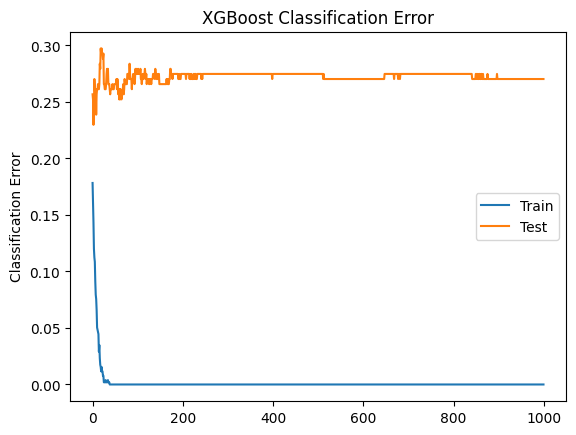

In [60]:
# e) Plot error with respect to number of estimators (trees)
XGB = XGBClassifier(
    n_estimators=N_trees,
    learning_rate=Learning_rate,
    max_depth=Max_depth,
    eval_metric=["auc", "error"]   # <-- put eval_metric here
)

# e) Fit model
eval_set = [(X_train, y_train), (X_test, y_test)]

trained_xgboost = XGB.fit(
    X_train,
    y_train,
    eval_set=eval_set,      # OK
    verbose=False           # OK
)

# predictions
real_test_predict = trained_xgboost.predict(X_test)
predictions = [round(value) for value in real_test_predict]

# retrieve performance metrics
results = trained_xgboost.evals_result()
epochs = len(results['validation_0']['error'])
x_axis = range(0, epochs)

fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['error'], label='Train')
ax.plot(x_axis, results['validation_1']['error'], label='Test')
ax.legend()
plt.ylabel('Classification Error')
plt.title('XGBoost Classification Error')
plt.show()

<a id="5e"></a> 
### E) LightGBM

In [61]:
# Import relevant package
import lightgbm as lgb
import time
from sklearn.metrics import f1_score,average_precision_score                    # f1 score of model

In [62]:
# Define X and y 
# X_variables = [''                 # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE

#               ]
# y_variable = ''

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

print(X_variables)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_M']


In [63]:
# a) Set model parameters 
N_trees           = 1000                           # Number of trees that are estimated
Max_depth         = 4                             # Maximum depth of each tree (nr of levels); -1 means no limit
Learning_rate     = 0.1                           # The learning rate ('eta')
Min_child_samples = 10                            # Minimum number of items per bucket
Min_child_weight  = 0.001                         # Minimum sum of instance weight (hessian) needed in a child (leaf).
Subsample         = 1                             # Subsample ratio of the training instance
Silent            = 1                             # Whether to print messages while running boosting
Num_leaves        = 70                            # Maximum number of leafs per tree

# Note: there are way more hyperparameters to tune. You can find them well-explained here: 
# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
# The values above are not tuned and optimized yet

In [64]:
# b) Estimate model
lgb_model = lgb.LGBMClassifier(
                         n_estimators=N_trees
                        ,max_depth=Max_depth 
                        ,learning_rate=Learning_rate
                        ,min_child_weight=Min_child_weight
                        ,min_child_samples=Min_child_samples
                        ,subsample=Subsample
                        ,num_leaves=Num_leaves
                        ,silent=Silent
                       )

lgb_model.fit(X_train, y_train)      # Fit the model over the train set

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 236, number of negative: 280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 314
[LightGBM] [Info] Number of data points in the train set: 516, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.457364 -> initscore=-0.170958
[LightGBM] [Info] Start training from score -0.170958
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

,boosting_type,'gbdt'
,num_leaves,70
,max_depth,4
,learning_rate,0.1
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [65]:
# c) Create predictions for the test set
preds_proba = lgb_model.predict_proba(X_test)
preds = lgb_model.predict(X_test)   # Cut-off point equals 0.5

# Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1)

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


,Prob. 0,Prob. 1,Prediction
0,1.000000,3.589395e-07,0
1,0.687628,3.123721e-01,0
2,0.000418,9.995816e-01,1
3,0.999032,9.683238e-04,0
4,0.011862,9.881384e-01,1
...,...,...,...
217,0.999738,2.623904e-04,0
218,0.999907,9.341779e-05,0
219,0.096256,9.037444e-01,1
220,0.007556,9.924436e-01,1


In [66]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0   1
row_0               
0             73  35
1             33  81


In [67]:
#    ii. Create classification report
#print(classification_report(y_test, preds))
f1_lgb_model = f1_score(y_test, preds)

Feature ranking:
Feature 2 (Cholesterol) 2787.000000
Feature 3 (MaxHR) 2152.000000
Feature 0 (Age) 1967.000000
Feature 1 (RestingBP) 1677.000000
Feature 4 (Oldpeak) 1065.000000
Feature 5 (Sex_M) 260.000000


<Figure size 750x500 with 0 Axes>

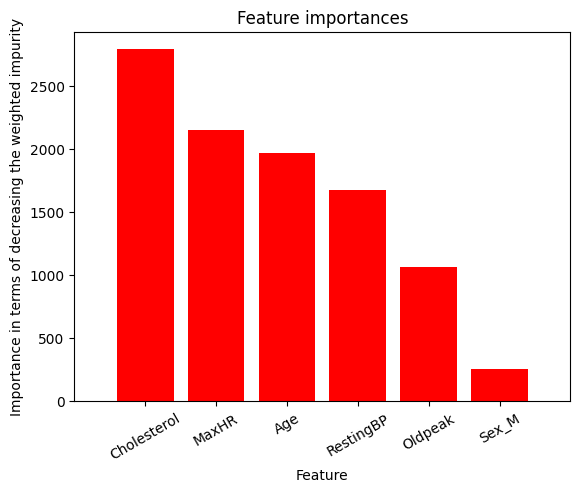

In [68]:
#    iii. Get the feature importances of the lgb_modeloost
importances = lgb_model.feature_importances_ 
std = np.std([lgb_model.feature_importances_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])


plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

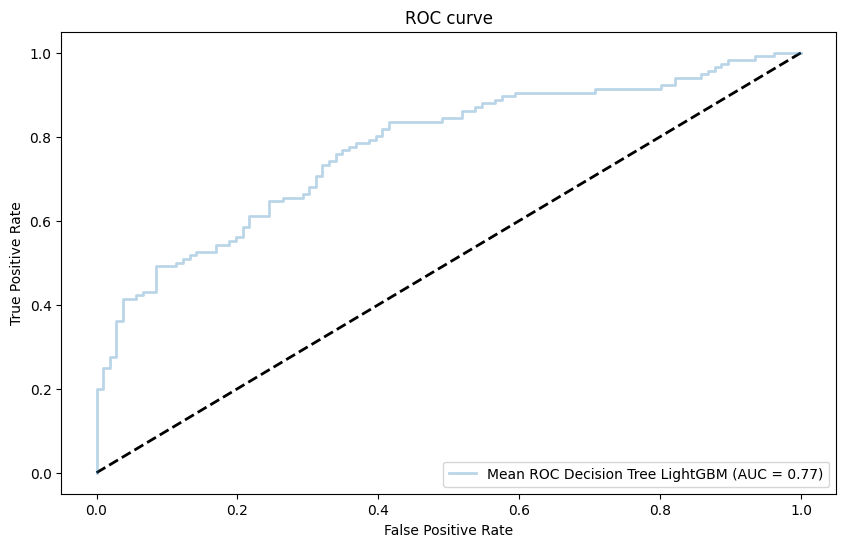

In [69]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
lgb_model_roc_auc_tree = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC Decision Tree LightGBM (AUC = %0.2f)' % (lgb_model_roc_auc_tree))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

<a id="5f"></a> 
### F) CatBoost

In [70]:
# Import relevant package
import catboost as cat
import time

In [71]:
# Define X and y 
X_variables = ['Age', 'RestingBP', 'Cholesterol', 'Sex']

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

In [72]:
# Because we use CatBoost, we can leverage its abilitiy to handle categoricals in a clever way
# For that, we need the column indices of the cat_features
cat_features=[X_variables.index("Sex")]

In [73]:
# a) Set model parameters 
N_trees        = 1000                          # Number of trees that are estimated
Max_depth      = 5                             # Maximum depth of each tree (nr of levels)
Learning_rate  = 1                             # The learning rate ('eta')
Subsample      = 1                             # Subsample ratio of the training instance
Silent         = True                          # Whether to print messages while running boosting

# Note: there are way more hyperparameters to tune. You can find them well-explained here: 
# https://catboost.ai/docs/concepts/parameter-tuning.html
# The values above are not tuned and optimized yet

In [74]:
# b) Estimate model
cat_model = cat.CatBoostClassifier(
                        n_estimators=N_trees
                        ,max_depth=Max_depth 
                        ,learning_rate=Learning_rate
                        ,subsample=Subsample
                        ,silent=Silent
                        ,cat_features=cat_features 
                       )
# You can uncomment the cat_features if you don't want to use this. 
# Given that we don't have many categories, this should not matter much. 
# But we leave it up to you to find out what the difference in speed and performance is!

cat_model.fit(X_train, y_train)      # Fit the model over the train set

In [75]:
# c) Create predictions for the test set
preds_proba = cat_model.predict_proba(X_test)
preds = cat_model.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.845263,0.154737,0
1,0.998780,0.001220,0
2,0.900548,0.099452,0
3,0.935019,0.064981,0
4,0.003071,0.996929,1


In [76]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

HeartDisease   0   1
row_0               
0             66  46
1             40  70


In [77]:
#    ii. Create classification report
#print(classification_report(y_test, preds))
f1_cat_model = f1_score(y_test, preds)

Feature ranking:
Feature 0 (Age) 34.249539
Feature 2 (Cholesterol) 33.947770
Feature 1 (RestingBP) 23.300829
Feature 3 (Sex) 8.501862


<Figure size 750x500 with 0 Axes>

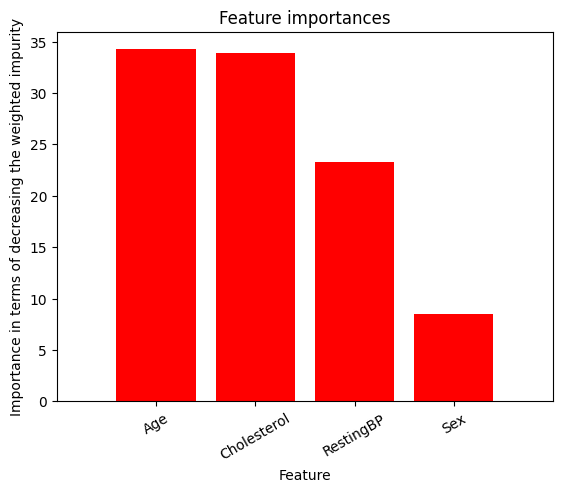

In [78]:
#    iii. Get the feature importances of the cat_modeloost
importances = cat_model.feature_importances_ 
std = np.std([cat_model.feature_importances_], axis=0)
indices = np.argsort(importances)[::-1]


importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])


plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

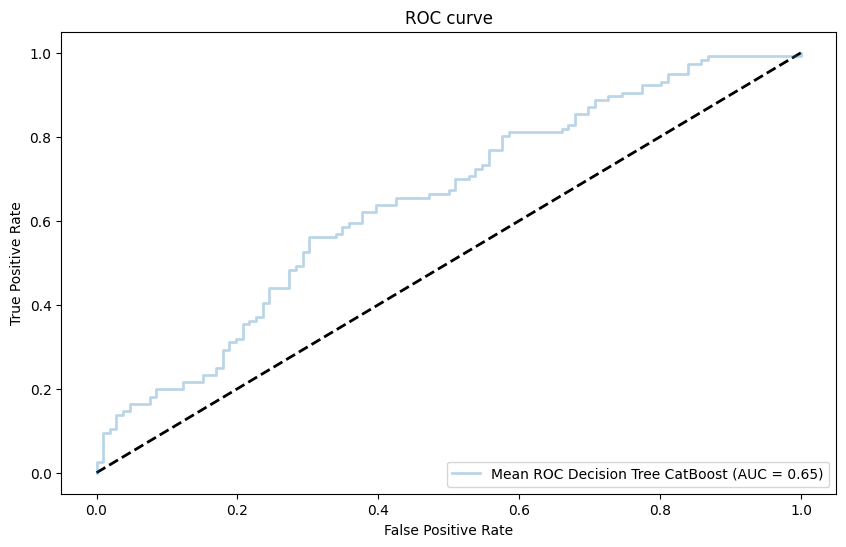

In [79]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#    v. Calculate AUC
cat_model_roc_auc_tree = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC Decision Tree CatBoost (AUC = %0.2f)' % (cat_model_roc_auc_tree))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

<a id="5g"></a> 
### G) Comparison of Models

In [80]:
print('AUC Decision Tree: CART', roc_auc_tree)
print('AUC Random Forest:', roc_auc_forest)
print('AUC Adaptive Boosting:', roc_auc_adaboost)
print('AUC XGBoost:', roc_auc_xgboost)
print('AUC LightGMB:', lgb_model_roc_auc_tree)
print('AUC CatBoost:', cat_model_roc_auc_tree)

AUC Decision Tree: CART 0.8071324007807417
AUC Random Forest: 0.8375081327260897
AUC Adaptive Boosting: 0.7904196486662328
AUC XGBoost: 0.7745608327911516
AUC LightGMB: 0.774316851008458
AUC CatBoost: 0.6461450878334417


<a id="6"></a> 
## 6. SHAP

In [81]:
import shap

c:\Users\WoutervanWessel\Documents\Coding\Tree Based Modelling\Cases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [82]:
# Define X and y 
X_variables = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','Sex_M'
               # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X_train = data_train.loc[:, X_variables]
y_train = data_train[y_variable]
X_test = data_test.loc[:, X_variables]
y_test = data_test[y_variable]

In [83]:
# Initialize shapley values for Random Forest with set X_test
explainer = shap.TreeExplainer(forest)
shap_values = explainer.shap_values(X_test)
preds = forest.predict(X_test)

In [84]:
# Check for indices with predictions = 1
X_test[preds==1]

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M
298,53,140.0,203,155.0,3.1,True
751,58,120.0,284,160.0,1.8,True
743,68,120.0,211,115.0,1.5,False
328,63,139.0,217,128.0,1.2,True
166,46,150.0,231,147.0,3.6,True
...,...,...,...,...,...,...
128,56,150.0,213,125.0,1.0,True
305,76,140.0,197,116.0,1.1,False
155,63,150.0,407,154.0,4.0,False
495,63,130.0,308,138.0,2.0,True


In [114]:
# Compute SHAP values
raw_shap = explainer.shap_values(X_test)
shap_values = raw_shap
base_value = explainer.expected_value

In [118]:
# Pick row 298
row = X_test.index.get_loc(298)

# Pick class 1
shap_row_class1 = shap_values[row, :, 1]   # shape = (6,)
base_value_class1 = explainer.expected_value[1]

# Convert row to DataFrame
row_df = X_test.iloc[[row]]

# Plot
shap.plots.force(
    base_value_class1,
    shap_row_class1,
    row_df
)


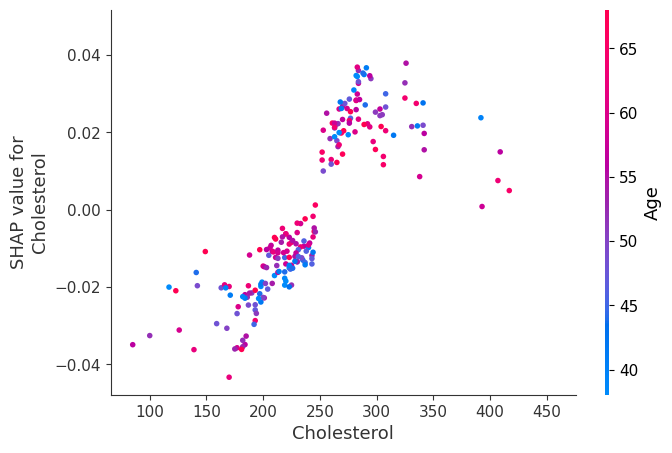

In [123]:
# For binary classification, select class 1
shap_values_class1 = shap_values[:, :, 1]   # shape = (n_samples, n_features)

# Dependence plot for 'Cholesterol'
shap.dependence_plot(
    'Cholesterol',
    shap_values_class1,
    X_test,
    xmax="percentile(99)"
)


#Question: What happens if you change the shap_values_class1 to shap_values[:, :, 0]? Why?

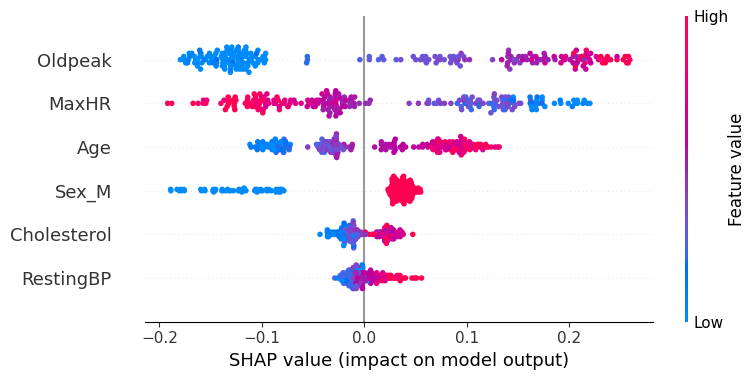

: 

In [ ]:
# Binary classification: pick class 1
shap_values_class1 = shap_values[:, :, 1]  # shape = (n_samples, n_features)

# Beeswarm summary plot
shap.summary_plot(shap_values_class1, X_test)


<a id="7"></a> 
## 7. Extra: K-fold cross validation

This last part is extra, on top of what you learned during class. You can do this when you understood all parts of the case and you still have time left. 

The idea behind K-fold cross validation is the following: note that the split between the training set and the test set is random. In order to correct for this randomness, we split the dataset into 'K' subsets, instead of only two. Next, we train the model K times, where each time, one of the K subsets functions as test set, and all the other subsets as training set. We then obtain the model parameters by taking the average over K different estimations. 

In [ ]:
# Define X and y 
X_variables = ['Age',
               'RestingBP',
               'Cholesterol',
               'Sex_F'        # ADJUST VARIABLES TO THOSE YOU WISH TO INCLUDE
              ]
y_variable = 'HeartDisease'

X = inputdata.loc[:, X_variables]
y = inputdata[y_variable]

In [ ]:
i = 0

# Define the number of splits and create dataframe for saving AUC's
N_splits = 10
aucs = pd.DataFrame(index=range(0,N_splits), columns=['Decision Tree','Random Forest','Adaboost','XGBoost'])

# Iterate models using K-fold cross validation for indexing train- and test set
kf = KFold(n_splits=N_splits, shuffle=False, random_state=random.seed())
for train_index, test_index in kf.split(inputdata):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Set model parameters 
    Min_num_splits = 3                           # Minimum number of items to split
    Min_bucket     = 3                           # Minimum number of items per bucket
    Max_depth      = 5                           # Maximum depth of final tree (nr of levels)
    N_trees        = 1000                           # Number of trees that are estimated
    Learning_rate  = 1                           # The learning rate (only applicable for Adaboost, XGBoost)
    Subsample      = 0.2                           # Subsample ratio of the training instance (only applicable for XGBoost)
    Silent         = 1                             # Whether to print messages while running boosting (only applicable for XGBoost)
    
    # a) Decision Tree CART
    j='Decision Tree'
    mytree = DecisionTreeClassifier(max_depth = Max_depth
                                 ,min_samples_split = Min_num_splits
                                 ,min_samples_leaf = Min_bucket
                                 ,criterion = "gini"              
                                 ,splitter = "best"
                                 ,random_state = random.seed()
                                 )
    mytree.fit(X_train, y_train)                    # Fit the model over the train set
    preds_proba = mytree.predict_proba(X_test)      # Calculate probabilities
    fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:, 1])  
    aucs.loc[i,j] = metrics.auc(fpr, tpr)           # Calculate AUC
    
    # b) Random Forest
    j='Random Forest'
    forest = RandomForestClassifier(n_estimators = N_trees
                               ,criterion = "gini"            
                               ,max_depth = Max_depth
                               ,min_samples_split = Min_num_splits
                               ,min_samples_leaf = Min_bucket
                               ,random_state = random.seed()
                               )
    forest.fit(X_train, y_train)                    # Fit the model over the train set
    preds_proba = forest.predict_proba(X_test)      # Calculate probabilities
    fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:, 1])  
    aucs.loc[i,j] = metrics.auc(fpr, tpr)           # Calculate AUC
    
    # c) Adaboost
    j='Adaboost'
    adaptboost = AdaBoostClassifier(n_estimators = N_trees
                                    ,base_estimator = DecisionTreeClassifier(max_depth = Max_depth
                                                                             ,min_samples_split = Min_num_splits
                                                                             ,min_samples_leaf = Min_bucket
                                                                             ,criterion = "gini"              
                                                                             ,splitter = "best"
                                                                             )
                                    ,learning_rate = Learning_rate
                                    )
    adaptboost.fit(X_train, y_train)                # Fit the model over the train set
    preds_proba = adaptboost.predict_proba(X_test)  # Calculate probabilities
    fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:, 1])  
    aucs.loc[i,j] = metrics.auc(fpr, tpr)           # Calculate AUC
    
    # d) XGBoost
    j='XGBoost'
    XGB = xgb.XGBClassifier(n_estimators = N_trees
                            ,max_depth = Max_depth 
                            ,learning_rate = Learning_rate
                            ,min_child_weight = Min_bucket
                            ,subsample = Subsample
                           )
    XGB.fit(X_train, y_train)                       # Fit the model over the train set
    preds_proba = XGB.predict_proba(X_test)         # Calculate probabilities
    fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:, 1])  
    aucs.loc[i,j] = metrics.auc(fpr, tpr)           # Calculate AUC
    
    # Go to next iteration
    i=i+1
    
# Evaluate the methods by looking at the average AUC
aucs.mean()    